# Domain Infrastructure Correlation

Identify shared infrastructure pivots across synthetic domain-registration and hosting observations.

**Safety and scope:** This notebook uses deterministic synthetic data and makes no network requests. Its results are analytical leads, not attribution or identity claims.

## Goal

Rank infrastructure clusters for analyst review without treating shared hosting as proof of common ownership.


## Setup

The workflow runs offline with NumPy and Pandas. Parameters and source-like fields are visible so the analysis can be reviewed and rerun.

### Key Assumptions

- All records are synthetic and contain no real people or infrastructure.
- Scores prioritize review; they do not prove ownership, intent, identity, or location.
- Real use requires documented authority, provenance, source terms, and retention limits.


In [1]:
import numpy as np
import pandas as pd

SEED = 88
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)


## Steps

### 1. Create bounded synthetic observations


In [2]:
domain_count = 72
infrastructure = pd.DataFrame({
    "domain": [f"example-{index:03d}.test" for index in range(domain_count)],
    "registrar": rng.choice(["Registrar-A", "Registrar-B", "Registrar-C"], domain_count, p=[0.45, 0.35, 0.20]),
    "nameserver": rng.choice([f"ns{index}.synthetic.net" for index in range(1, 9)], domain_count),
    "asn": rng.choice([64510, 64511, 64512, 64513, 64514], domain_count),
    "domain_age_days": rng.integers(2, 1800, domain_count),
    "rare_tld": rng.binomial(1, 0.18, domain_count),
    "privacy_service": rng.binomial(1, 0.42, domain_count),
})
infrastructure["observed_alert"] = (
    (infrastructure["domain_age_days"] < 45)
    & (infrastructure["rare_tld"] == 1)
).astype(int)
print(infrastructure.head(6).to_string(index=False))


          domain   registrar        nameserver   asn  domain_age_days  rare_tld  privacy_service  observed_alert
example-000.test Registrar-A ns8.synthetic.net 64513              281         1                0               0
example-001.test Registrar-B ns2.synthetic.net 64510             1723         0                1               0
example-002.test Registrar-B ns8.synthetic.net 64510              175         0                0               0
example-003.test Registrar-B ns5.synthetic.net 64514             1256         0                0               0
example-004.test Registrar-B ns8.synthetic.net 64513              149         0                0               0
example-005.test Registrar-A ns6.synthetic.net 64513              587         0                1               0


### 2. Analyze and rank the observations


In [3]:
cluster_summary = (
    infrastructure.groupby(["nameserver", "asn"], as_index=False)
    .agg(domains=("domain", "count"), alerts=("observed_alert", "sum"), median_age=("domain_age_days", "median"))
)
cluster_summary["review_score"] = (
    0.45 * np.minimum(cluster_summary["domains"] / 8, 1)
    + 0.40 * np.minimum(cluster_summary["alerts"] / 3, 1)
    + 0.15 * (cluster_summary["median_age"] < 90)
).round(3)
ranked_clusters = cluster_summary.sort_values(["review_score", "domains"], ascending=False)
print(ranked_clusters.head(8).to_string(index=False))


       nameserver   asn  domains  alerts  median_age  review_score
ns5.synthetic.net 64510        1       1         9.0         0.340
ns1.synthetic.net 64512        5       0      1512.0         0.281
ns7.synthetic.net 64514        5       0       919.0         0.281
ns8.synthetic.net 64513        5       0       586.0         0.281
ns2.synthetic.net 64513        4       0       732.0         0.225
ns7.synthetic.net 64510        4       0       185.5         0.225
ns2.synthetic.net 64510        3       0       951.0         0.169
ns4.synthetic.net 64514        3       0       879.0         0.169


## Visual Insights & ML Extension

This section adds a polished visual story and a project-appropriate machine-learning extension while preserving the original transparent score or aggregation. Supervised labels are synthetic evaluation aids; unsupervised clusters and anomalies are review leads only.

**Interpretation boundary:** these results do not prove identity, ownership, intent, attribution, or location. Real use requires lawful authority, source provenance, independent corroboration, and retention controls.


Model comparison (held-out data):
                     roc_auc  average_precision  f1_at_0_5
model                                                     
Logistic regression      1.0                1.0      0.889
Random forest            1.0                1.0      1.000

Analyst takeaways:
- Best average precision: Logistic regression (1.000).
- The top-scored review decile contains 5.5× the baseline positive rate.
- Strongest random-forest driver: domain age days.
- These are synthetic review leads; independent corroboration and documented provenance remain mandatory.


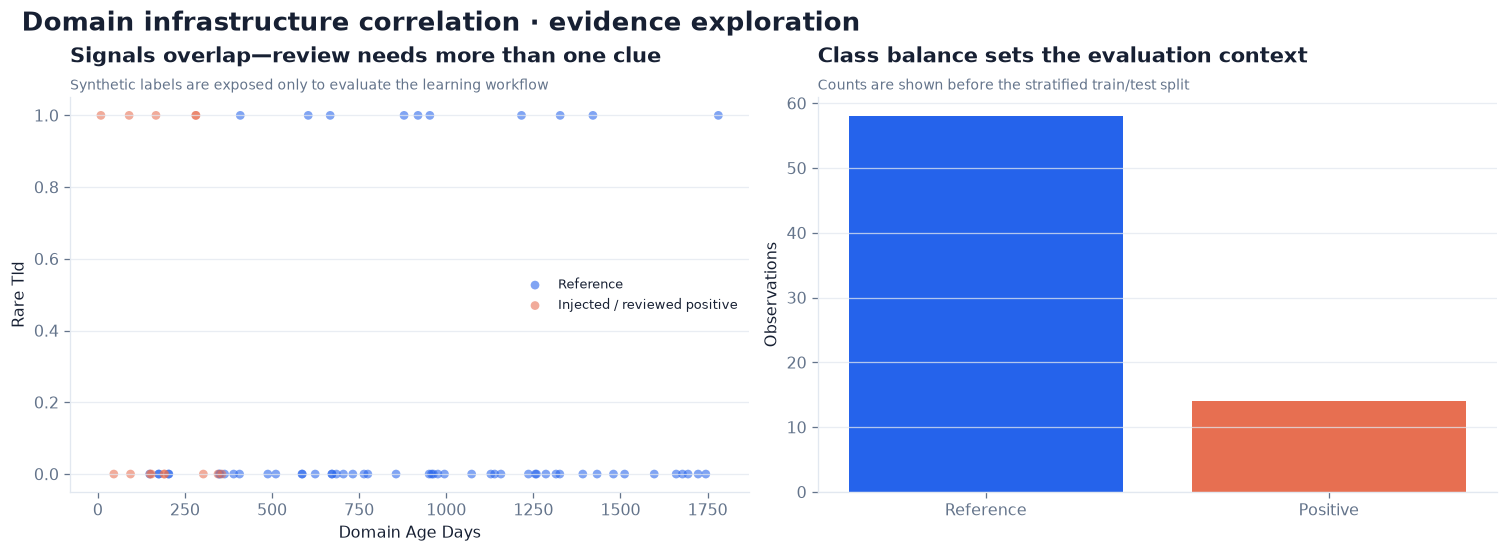

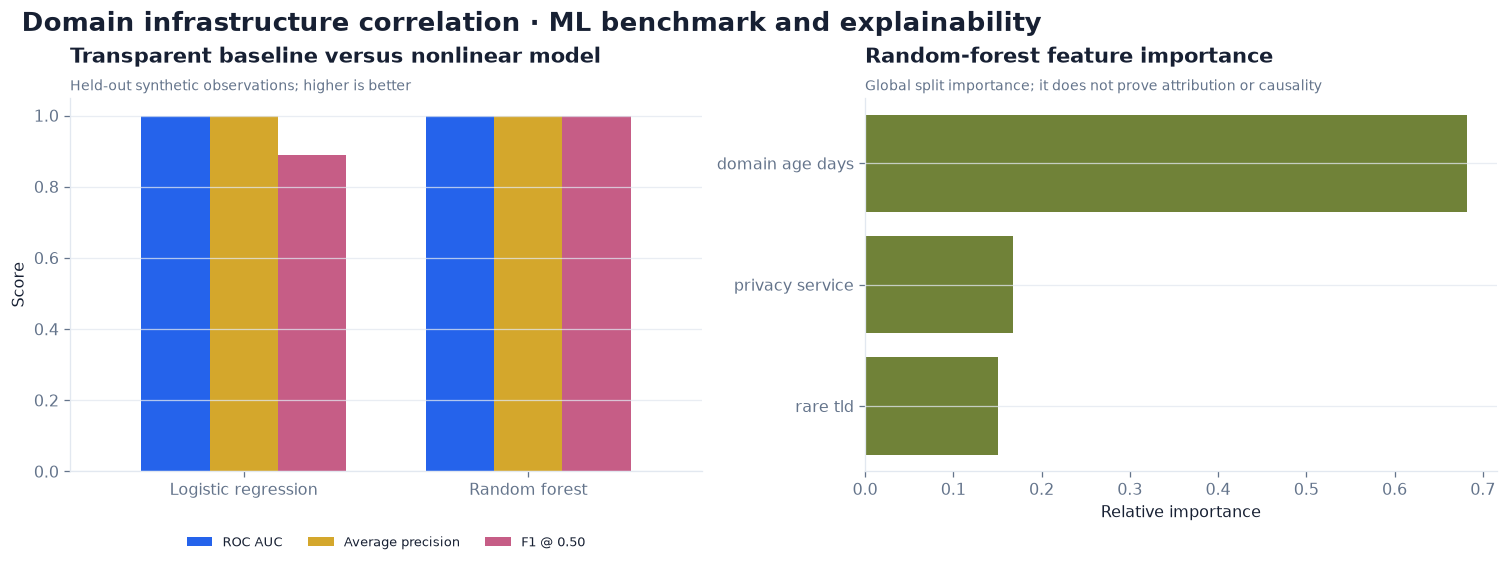

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, r2_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 88)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def compare_binary_models(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows, probabilities, fitted = [], {}, {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

infrastructure["simulated_review_label"] = ((infrastructure["domain_age_days"] < 365) & ((infrastructure["rare_tld"] == 1) | (infrastructure["privacy_service"] == 1))).astype(int)
ml_frame = infrastructure.copy()
ml_features = ml_frame[['domain_age_days', 'rare_tld', 'privacy_service']]
ml_labels = ml_frame["simulated_review_label"].to_numpy(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)
for class_value, color, class_name in [
    (0, PALETTE["blue"], "Reference"),
    (1, PALETTE["orange"], "Injected / reviewed positive"),
]:
    subset = ml_frame[ml_frame["simulated_review_label"] == class_value]
    axes[0].scatter(subset["domain_age_days"], subset["rare_tld"], s=30, alpha=0.58, color=color, edgecolors="none", label=class_name)
axes[0].legend(frameon=False, fontsize=8)
polish_axis(
    axes[0],
    "Signals overlap—review needs more than one clue",
    "Synthetic labels are exposed only to evaluate the learning workflow",
    "Domain Age Days",
    "Rare Tld",
)

class_counts = ml_frame["simulated_review_label"].value_counts().sort_index()
axes[1].bar(["Reference", "Positive"], class_counts.reindex([0, 1], fill_value=0), color=[PALETTE["blue"], PALETTE["orange"]])
polish_axis(axes[1], "Class balance sets the evaluation context", "Counts are shown before the stratified train/test split", "", "Observations")
fig.suptitle("Domain infrastructure correlation · evidence exploration", fontsize=16, fontweight="bold", x=0.01, ha="left")

model_comparison, fitted_models, model_probabilities, test_labels = compare_binary_models(ml_features, ml_labels)
forest = fitted_models["Random forest"]
feature_importance = pd.Series(forest.feature_importances_, index=ml_features.columns).sort_values(ascending=False)
best_model = model_comparison["average_precision"].idxmax()
best_probability = model_probabilities[best_model]
review_count = max(1, int(len(best_probability) * 0.10))
top_positions = np.argsort(best_probability)[-review_count:]
test_labels_array = np.asarray(test_labels)
top_rate = float(test_labels_array[top_positions].mean())
baseline_rate = float(test_labels_array.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
comparison_display = model_comparison.rename(columns={
    "roc_auc": "ROC AUC",
    "average_precision": "Average precision",
    "f1_at_0_5": "F1 @ 0.50",
})
comparison_display.plot(kind="bar", ax=axes[0], color=[PALETTE["blue"], PALETTE["gold"], PALETTE["pink"]], width=0.72)
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14))
polish_axis(axes[0], "Transparent baseline versus nonlinear model", "Held-out synthetic observations; higher is better", "", "Score")

importance_to_plot = feature_importance.head(7).sort_values()
axes[1].barh(importance_to_plot.index.str.replace("_", " "), importance_to_plot.values, color=PALETTE["olive"])
polish_axis(axes[1], "Random-forest feature importance", "Global split importance; it does not prove attribution or causality", "Relative importance", "")
fig.suptitle("Domain infrastructure correlation · ML benchmark and explainability", fontsize=16, fontweight="bold", x=0.01, ha="left")

print("Model comparison (held-out data):")
print(model_comparison.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- Best average precision: {best_model} ({model_comparison.loc[best_model, 'average_precision']:.3f}).")
print(f"- The top-scored review decile contains {top_rate / max(baseline_rate, 1e-9):.1f}× the baseline positive rate.")
print(f"- Strongest random-forest driver: {feature_importance.index[0].replace('_', ' ')}.")
print("- These are synthetic review leads; independent corroboration and documented provenance remain mandatory.")


## Checks

Run deterministic integrity and reasonableness checks.


In [5]:
assert infrastructure["domain"].is_unique
assert ranked_clusters["review_score"].between(0, 1).all()
assert ranked_clusters["domains"].sum() == len(infrastructure)
print("Checks passed; shared infrastructure remains a review lead, not an attribution claim.")


Checks passed; shared infrastructure remains a review lead, not an attribution claim.


## Next Steps

- Add passive-DNS timestamps and source provenance.
- Require an independent signal before escalating a cluster.
